# Burn Scar Detection: QA Impact Analysis Report

**Comparison of Predicted Burn Scar Perimeter with and without Quality Assurance (QA) Masks**

---

This report compares two NBR-based burn scar detection approaches:
1. **Curated Pipeline (with QA)**: Applies multiple quality assurance masks
2. **Non-Curated Pipeline (without QA)**: Basic NBR calculation without masking

The goal is to quantify how QA masks affect the predicted burn scar **perimeter**, **area**, and **accuracy** compared to a reference dataset.

## 1. Setup and Configuration

In [1]:
import os
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

%matplotlib inline

In [2]:
# Define paths
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
OUTPUT_DIR = os.path.join(BASE_DIR, 'output')

# Paths to comparison results
QA_DIR = os.path.join(OUTPUT_DIR, 'with_qa')
NO_QA_DIR = os.path.join(OUTPUT_DIR, 'non_qa')

# Paths to metrics files
QA_METRICS = os.path.join(QA_DIR, 'comparison_metrics.csv')
NO_QA_METRICS = os.path.join(NO_QA_DIR, 'comparison_metrics.csv')

# Paths to polygon files
QA_POLYGON = os.path.join(QA_DIR, 'burn_polygon_with_qa.gpkg')
NO_QA_POLYGON = os.path.join(NO_QA_DIR, 'burn_polygon_no_qa.gpkg')

# Path to reference (adjust as needed)
REFERENCE_POLYGON = os.path.join(BASE_DIR, 'data', 'true_perimeter.geojson')

# Output directory for report figures
REPORT_DIR = os.path.join(OUTPUT_DIR, 'report')
os.makedirs(REPORT_DIR, exist_ok=True)

print(f"Report outputs will be saved to: {REPORT_DIR}")

Report outputs will be saved to: c:\Repos\ARua_Wildfire\output\report


## 2. Load Comparison Metrics

In [3]:
# Load metrics from both pipelines
try:
    qa_metrics_df = pd.read_csv(QA_METRICS)
    no_qa_metrics_df = pd.read_csv(NO_QA_METRICS)
    print("✓ Metrics loaded successfully")
except FileNotFoundError as e:
    print(f"❌ Error: {e}")
    print("Please ensure both pipelines have been executed and metrics files exist.")

✓ Metrics loaded successfully


In [4]:
# Display metrics side by side
print("\n=== WITH QA METRICS ===")
display(qa_metrics_df)

print("\n=== WITHOUT QA METRICS ===")
display(no_qa_metrics_df)


=== WITH QA METRICS ===


,Metric,Value
0,Reference Area (ha),33002.942462
1,Predicted Area (ha),33387.360000
2,Area Difference (ha),384.417538
3,Area Difference (%),1.164798
4,Reference Perimeter (km),2814.112782
5,Predicted Perimeter (km),1041.240000
6,Perimeter Difference (%),-1772.872782
7,Perimeter_Difference (%),-62.999351
8,Intersection (ha),31356.543064
9,Union (ha),35033.759399



=== WITHOUT QA METRICS ===


,Metric,Value
0,Reference Area (ha),33002.942462
1,Predicted Area (ha),37285.120000
2,Area Difference (ha),4282.177538
3,Area Difference (%),12.975139
4,Reference Perimeter (km),2814.112782
5,Predicted Perimeter (km),391.440000
6,Perimeter Difference (%),-2422.672782
7,Perimeter_Difference (%),-86.090110
8,Intersection (ha),32950.662752
9,Union (ha),37337.399711


## 3. Perimeter Comparison Analysis

In [5]:
# Extract key perimeter metrics
def get_metric_value(df, metric_name):
    """Extract a metric value from the metrics dataframe"""
    row = df[df['Metric'] == metric_name]
    if len(row) > 0:
        return row['Value'].values[0]
    return None

# Reference perimeter (should be same in both)
ref_perimeter = get_metric_value(qa_metrics_df, 'Reference Perimeter (km)')

# Predicted perimeters
qa_perimeter = get_metric_value(qa_metrics_df, 'Predicted Perimeter (km)')
no_qa_perimeter = get_metric_value(no_qa_metrics_df, 'Predicted Perimeter (km)')

# Perimeter differences from reference
qa_perim_diff_pct = get_metric_value(qa_metrics_df, 'Perimeter_Difference (%)')
no_qa_perim_diff_pct = get_metric_value(no_qa_metrics_df, 'Perimeter_Difference (%)')

print("\n" + "="*60)
print("PERIMETER COMPARISON SUMMARY")
print("="*60)
print(f"\nReference Perimeter:      {ref_perimeter:>10.2f} km")
print(f"\nPredicted (with QA):      {qa_perimeter:>10.2f} km ({qa_perim_diff_pct:>+7.2f}%)")
print(f"Predicted (without QA):   {no_qa_perimeter:>10.2f} km ({no_qa_perim_diff_pct:>+7.2f}%)")
print(f"\nDifference (QA impact):   {qa_perimeter - no_qa_perimeter:>10.2f} km")
print(f"Relative change:          {((qa_perimeter/no_qa_perimeter - 1)*100):>+10.2f}%")
print("="*60)


PERIMETER COMPARISON SUMMARY

Reference Perimeter:         2814.11 km

Predicted (with QA):         1041.24 km ( -63.00%)
Predicted (without QA):       391.44 km ( -86.09%)

Difference (QA impact):       649.80 km
Relative change:             +166.00%


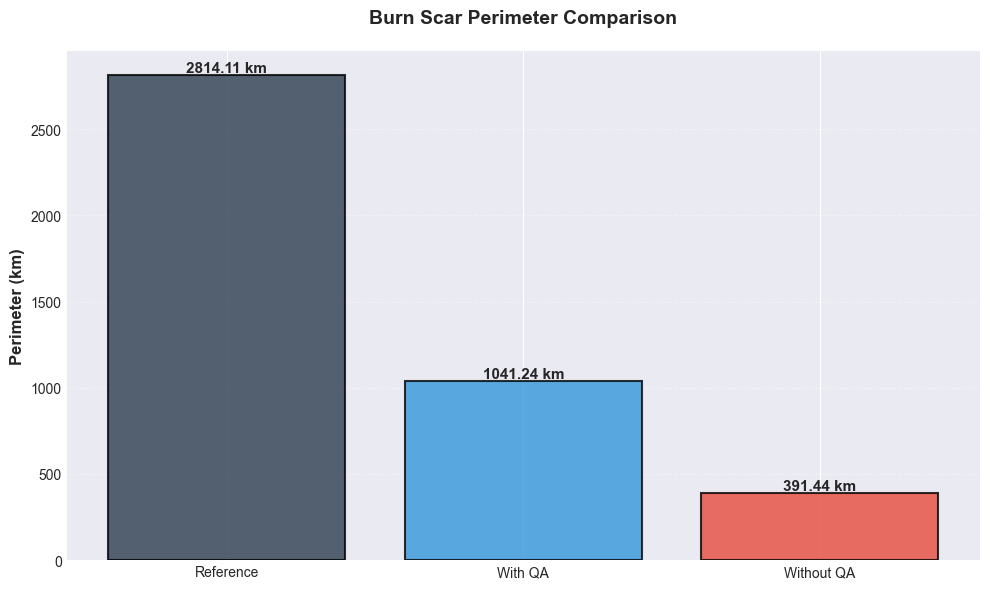

✓ Saved to: c:\Repos\ARua_Wildfire\output\report\perimeter_comparison.png


In [6]:
# Visualize perimeter comparison
fig, ax = plt.subplots(figsize=(10, 6))

categories = ['Reference', 'With QA', 'Without QA']
perimeters = [ref_perimeter, qa_perimeter, no_qa_perimeter]
colors = ['#2C3E50', '#3498DB', '#E74C3C']

bars = ax.bar(categories, perimeters, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar, val in zip(bars, perimeters):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.2f} km',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylabel('Perimeter (km)', fontsize=12, fontweight='bold')
ax.set_title('Burn Scar Perimeter Comparison', fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, 'perimeter_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved to: {os.path.join(REPORT_DIR, 'perimeter_comparison.png')}")

## 4. Area Comparison Analysis

In [7]:
# Extract area metrics
ref_area = get_metric_value(qa_metrics_df, 'Reference Area (ha)')
qa_area = get_metric_value(qa_metrics_df, 'Predicted Area (ha)')
no_qa_area = get_metric_value(no_qa_metrics_df, 'Predicted Area (ha)')

qa_area_diff_pct = get_metric_value(qa_metrics_df, 'Area Difference (%)')
no_qa_area_diff_pct = get_metric_value(no_qa_metrics_df, 'Area Difference (%)')

print("\n" + "="*60)
print("AREA COMPARISON SUMMARY")
print("="*60)
print(f"\nReference Area:           {ref_area:>10.2f} ha")
print(f"\nPredicted (with QA):      {qa_area:>10.2f} ha ({qa_area_diff_pct:>+7.2f}%)")
print(f"Predicted (without QA):   {no_qa_area:>10.2f} ha ({no_qa_area_diff_pct:>+7.2f}%)")
print(f"\nDifference (QA impact):   {qa_area - no_qa_area:>10.2f} ha")
print(f"Relative change:          {((qa_area/no_qa_area - 1)*100):>+10.2f}%")
print("="*60)


AREA COMPARISON SUMMARY

Reference Area:             33002.94 ha

Predicted (with QA):        33387.36 ha (  +1.16%)
Predicted (without QA):     37285.12 ha ( +12.98%)

Difference (QA impact):     -3897.76 ha
Relative change:              -10.45%


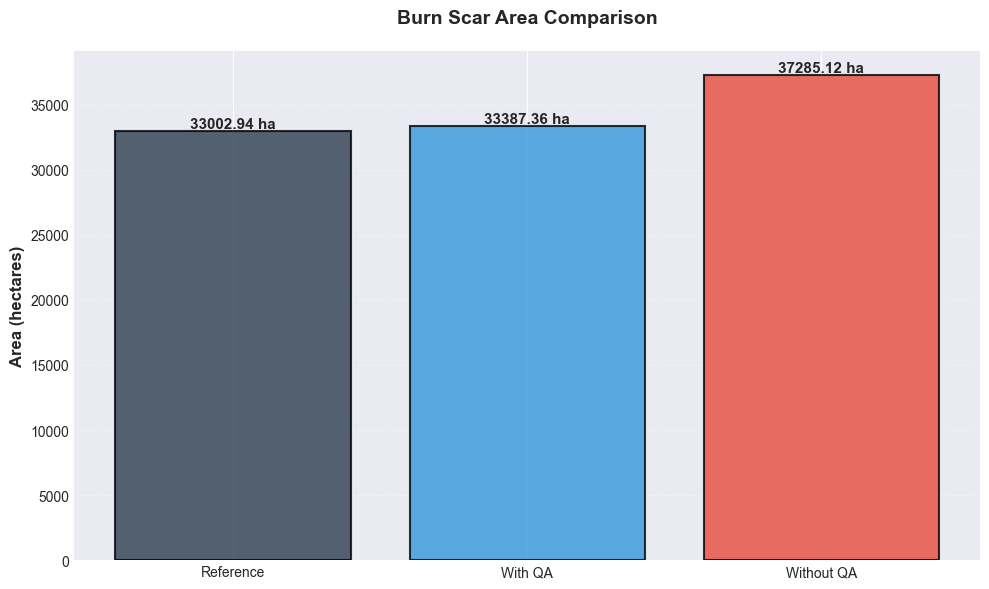

✓ Saved to: c:\Repos\ARua_Wildfire\output\report\area_comparison.png


In [8]:
# Visualize area comparison
fig, ax = plt.subplots(figsize=(10, 6))

areas = [ref_area, qa_area, no_qa_area]

bars = ax.bar(categories, areas, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar, val in zip(bars, areas):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.2f} ha',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylabel('Area (hectares)', fontsize=12, fontweight='bold')
ax.set_title('Burn Scar Area Comparison', fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, 'area_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved to: {os.path.join(REPORT_DIR, 'area_comparison.png')}")

## 5. Fire Severity Distribution Analysis

**CRITICAL RESEARCH QUESTION**: Does QA meaningfully change fire severity results?

Specifically, we examine:
1. **Structural changes**: Redistribution from High → Moderate severity classes
2. **Statistical significance**: Are differences meaningful or within noise?

In [9]:
# Paths to severity area outputs (adjust based on your actual output structure)
# These should be CSVs or similar outputs from the severity_area() function

# Option 1: If severity_area saves CSV files
QA_SEVERITY_AREA = os.path.join(QA_DIR, 'severity_area.csv')
NO_QA_SEVERITY_AREA = os.path.join(NO_QA_DIR, 'severity_area.csv')

# Option 2: If you need to load from the severity rasters directly
QA_SEVERITY_RASTER = os.path.join(QA_DIR, 'severity_with_qa.tif')
NO_QA_SEVERITY_RASTER = os.path.join(NO_QA_DIR, 'severity_no_qa.tif')
QA_POLYGON = os.path.join(QA_DIR, 'burn_polygons_with_qa.gpkg')
NO_QA_POLYGON = os.path.join(NO_QA_DIR, 'burn_polygons_no_qa.gpkg')

In [10]:
import rasterio
from rasterio.mask import mask
from shapely.ops import unary_union

def calculate_severity_distribution(severity_path, polygon_path):
    """
    Calculate severity class distribution within burn polygon
    
    Returns: DataFrame with severity class areas
    """
    # Severity labels
    severity_labels = {
        0: "Unburned",
        1: "Low",
        2: "Moderate-Low",
        3: "Moderate-High",
        4: "High"
    }
    
    # Load polygon and dissolve
    polygon_gdf = gpd.read_file(polygon_path)
    if polygon_gdf.crs != "EPSG:32629":
        polygon_gdf = polygon_gdf.to_crs("EPSG:32629")
    
    polygon_geom = unary_union(polygon_gdf.geometry)
    shapes_geom = [polygon_geom.__geo_interface__] if polygon_geom.geom_type != "GeometryCollection" else \
                  [g.__geo_interface__ for g in polygon_geom.geoms]
    
    # Load severity raster and mask to polygon
    with rasterio.open(severity_path) as src:
        severity_meta = src.meta.copy()
        severity_data, transform = mask(
            src,
            shapes_geom,
            crop=True,
            nodata=255,
            filled=False
        )
        severity = severity_data[0]
        
        # Calculate pixel area in hectares
        pixel_area_ha = abs(severity_meta["transform"].a * severity_meta["transform"].e) / 10_000
    
    # Remove masked pixels and count
    severity_flat = severity[~severity.mask]
    unique, counts = np.unique(severity_flat, return_counts=True)
    
    # Build distribution table
    area_table = []
    for val, cnt in zip(unique, counts):
        if val not in severity_labels:
            continue
        area_ha = cnt * pixel_area_ha
        area_table.append({
            "severity_class": int(val),
            "severity_label": severity_labels[int(val)],
            "area_ha": area_ha,
            "pixel_count": cnt
        })
    
    df = pd.DataFrame(area_table).sort_values("severity_class")
    
    # Add percentage
    total_area = df['area_ha'].sum()
    df['percentage'] = (df['area_ha'] / total_area * 100)
    
    return df

# Calculate distributions
try:
    # Try loading from CSV first
    qa_severity_df = pd.read_csv(QA_SEVERITY_AREA)
    no_qa_severity_df = pd.read_csv(NO_QA_SEVERITY_AREA)
    print("✓ Loaded severity area CSVs")
except FileNotFoundError:
    # Calculate from rasters
    print("CSV files not found. Calculating from rasters...")
    qa_severity_df = calculate_severity_distribution(QA_SEVERITY_RASTER, QA_POLYGON)
    no_qa_severity_df = calculate_severity_distribution(NO_QA_SEVERITY_RASTER, NO_QA_POLYGON)
    print("✓ Calculated severity distributions")

CSV files not found. Calculating from rasters...
✓ Calculated severity distributions


In [11]:
print("\n" + "="*70)
print("SEVERITY DISTRIBUTION - WITH QA")
print("="*70)
display(qa_severity_df)

print("\n" + "="*70)
print("SEVERITY DISTRIBUTION - WITHOUT QA")
print("="*70)
display(no_qa_severity_df)


SEVERITY DISTRIBUTION - WITH QA


,severity_class,severity_label,area_ha,pixel_count,percentage
0,0,Unburned,304.08,7602,0.950825
1,1,Low,1521.72,38043,4.758254
2,2,Moderate-Low,12790.96,319774,39.995948
3,3,Moderate-High,16116.52,402913,50.394614
4,4,High,1247.36,31184,3.900360



SEVERITY DISTRIBUTION - WITHOUT QA


,severity_class,severity_label,area_ha,pixel_count,percentage
0,0,Unburned,1602.88,40072,4.298980
1,1,Low,5053.92,126348,13.554791
2,2,Moderate-Low,15269.72,381743,40.953925
3,3,Moderate-High,14630.44,365761,39.239353
4,4,High,728.16,18204,1.952951


In [12]:
# Create comparison table
comparison_df = pd.DataFrame({
    'Severity Class': qa_severity_df['severity_label'],
    'With QA (ha)': qa_severity_df['area_ha'],
    'With QA (%)': qa_severity_df['percentage'],
    'Without QA (ha)': no_qa_severity_df['area_ha'],
    'Without QA (%)': no_qa_severity_df['percentage']
})

# Calculate differences
comparison_df['Difference (ha)'] = comparison_df['With QA (ha)'] - comparison_df['Without QA (ha)']
comparison_df['Difference (%)'] = comparison_df['With QA (%)'] - comparison_df['Without QA (%)']
comparison_df['Relative Change (%)'] = ((comparison_df['With QA (ha)'] / comparison_df['Without QA (ha)'] - 1) * 100)

print("\n" + "="*100)
print("SEVERITY CLASS COMPARISON")
print("="*100)
display(comparison_df.style.format({
    'With QA (ha)': '{:.2f}',
    'With QA (%)': '{:.2f}',
    'Without QA (ha)': '{:.2f}',
    'Without QA (%)': '{:.2f}',
    'Difference (ha)': '{:+.2f}',
    'Difference (%)': '{:+.2f}',
    'Relative Change (%)': '{:+.2f}'
}))

# Save comparison
comparison_path = os.path.join(REPORT_DIR, 'severity_comparison.csv')
comparison_df.to_csv(comparison_path, index=False)
print(f"\n✓ Severity comparison saved to: {comparison_path}")


SEVERITY CLASS COMPARISON


,Severity Class,With QA (ha),With QA (%),Without QA (ha),Without QA (%),Difference (ha),Difference (%),Relative Change (%)
0,Unburned,304.08,0.95,1602.88,4.30,-1298.80,-3.35,-81.03
1,Low,1521.72,4.76,5053.92,13.55,-3532.20,-8.80,-69.89
2,Moderate-Low,12790.96,40.00,15269.72,40.95,-2478.76,-0.96,-16.23
3,Moderate-High,16116.52,50.39,14630.44,39.24,+1486.08,+11.16,+10.16
4,High,1247.36,3.90,728.16,1.95,+519.20,+1.95,+71.30



✓ Severity comparison saved to: c:\Repos\ARua_Wildfire\output\report\severity_comparison.csv


In [13]:
# Focus on High → Moderate redistribution
print("\n" + "="*80)
print("STRUCTURAL CHANGE ANALYSIS: High → Moderate Redistribution")
print("="*80)

# Extract key classes
high_qa = comparison_df[comparison_df['Severity Class'] == 'High']['With QA (ha)'].values[0]
high_no_qa = comparison_df[comparison_df['Severity Class'] == 'High']['Without QA (ha)'].values[0]

mod_high_qa = comparison_df[comparison_df['Severity Class'] == 'Moderate-High']['With QA (ha)'].values[0]
mod_high_no_qa = comparison_df[comparison_df['Severity Class'] == 'Moderate-High']['Without QA (ha)'].values[0]

mod_low_qa = comparison_df[comparison_df['Severity Class'] == 'Moderate-Low']['With QA (ha)'].values[0]
mod_low_no_qa = comparison_df[comparison_df['Severity Class'] == 'Moderate-Low']['Without QA (ha)'].values[0]

# Calculate changes
high_change = high_qa - high_no_qa
high_change_pct = (high_change / high_no_qa) * 100

mod_high_change = mod_high_qa - mod_high_no_qa
mod_high_change_pct = (mod_high_change / mod_high_no_qa) * 100

mod_low_change = mod_low_qa - mod_low_no_qa
mod_low_change_pct = (mod_low_change / mod_low_no_qa) * 100

print(f"\n📊 HIGH SEVERITY:")
print(f"   Without QA: {high_no_qa:>10.2f} ha")
print(f"   With QA:    {high_qa:>10.2f} ha")
print(f"   Change:     {high_change:>+10.2f} ha ({high_change_pct:>+7.2f}%)")

print(f"\n📊 MODERATE-HIGH SEVERITY:")
print(f"   Without QA: {mod_high_no_qa:>10.2f} ha")
print(f"   With QA:    {mod_high_qa:>10.2f} ha")
print(f"   Change:     {mod_high_change:>+10.2f} ha ({mod_high_change_pct:>+7.2f}%)")

print(f"\n📊 MODERATE-LOW SEVERITY:")
print(f"   Without QA: {mod_low_no_qa:>10.2f} ha")
print(f"   With QA:    {mod_low_qa:>10.2f} ha")
print(f"   Change:     {mod_low_change:>+10.2f} ha ({mod_low_change_pct:>+7.2f}%)")

# Calculate total moderate (for combined analysis)
total_mod_qa = mod_high_qa + mod_low_qa
total_mod_no_qa = mod_high_no_qa + mod_low_no_qa
total_mod_change = total_mod_qa - total_mod_no_qa

print(f"\n📊 TOTAL MODERATE (Moderate-High + Moderate-Low):")
print(f"   Without QA: {total_mod_no_qa:>10.2f} ha")
print(f"   With QA:    {total_mod_qa:>10.2f} ha")
print(f"   Change:     {total_mod_change:>+10.2f} ha ({(total_mod_change/total_mod_no_qa)*100:>+7.2f}%)")

# Check for redistribution pattern
print("\n" + "="*80)
print("REDISTRIBUTION PATTERN DETECTION")
print("="*80)

# Mass balance check
if high_change < 0 and total_mod_change > 0:
    redistribution_amount = min(abs(high_change), total_mod_change)
    print(f"\n✓ REDISTRIBUTION DETECTED: High → Moderate")
    print(f"  Estimated redistribution: ~{redistribution_amount:.2f} ha")
    print(f"  ({abs(high_change_pct):.1f}% reduction in High severity)")
elif high_change > 0 and total_mod_change < 0:
    print(f"\n⚠ REVERSE REDISTRIBUTION: Moderate → High")
    print(f"  ({high_change_pct:+.1f}% increase in High severity)")
else:
    print(f"\n○ NO CLEAR REDISTRIBUTION PATTERN")
    print(f"  Changes may be due to total area differences rather than severity shifts")

print("\n" + "="*80)


STRUCTURAL CHANGE ANALYSIS: High → Moderate Redistribution

📊 HIGH SEVERITY:
   Without QA:     728.16 ha
   With QA:       1247.36 ha
   Change:        +519.20 ha ( +71.30%)

📊 MODERATE-HIGH SEVERITY:
   Without QA:   14630.44 ha
   With QA:      16116.52 ha
   Change:       +1486.08 ha ( +10.16%)

📊 MODERATE-LOW SEVERITY:
   Without QA:   15269.72 ha
   With QA:      12790.96 ha
   Change:       -2478.76 ha ( -16.23%)

📊 TOTAL MODERATE (Moderate-High + Moderate-Low):
   Without QA:   29900.16 ha
   With QA:      28907.48 ha
   Change:        -992.68 ha (  -3.32%)

REDISTRIBUTION PATTERN DETECTION

⚠ REVERSE REDISTRIBUTION: Moderate → High
  (+71.3% increase in High severity)



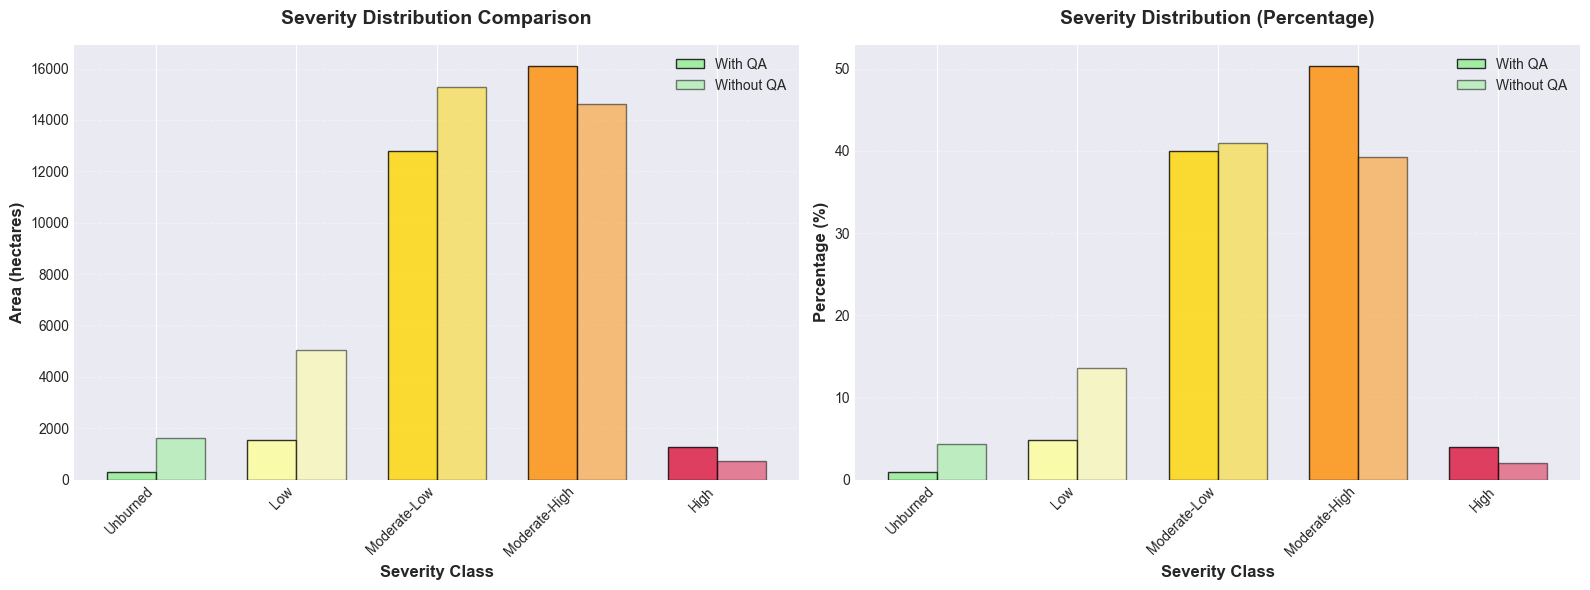

✓ Saved to: c:\Repos\ARua_Wildfire\output\report\severity_distribution.png


In [14]:
# Create stacked bar chart comparing severity distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Prepare data
severity_classes = comparison_df['Severity Class'].tolist()
qa_areas = comparison_df['With QA (ha)'].tolist()
no_qa_areas = comparison_df['Without QA (ha)'].tolist()

# Color scheme (low to high severity)
severity_colors = {
    'Unburned': '#90EE90',      # Light green
    'Low': '#FFFF99',           # Light yellow
    'Moderate-Low': '#FFD700',  # Gold
    'Moderate-High': '#FF8C00', # Dark orange  
    'High': '#DC143C'           # Crimson
}

colors = [severity_colors.get(sc, '#808080') for sc in severity_classes]

# Plot 1: Side-by-side bars
x = np.arange(len(severity_classes))
width = 0.35

bars1 = ax1.bar(x - width/2, qa_areas, width, label='With QA', 
                color=colors, alpha=0.8, edgecolor='black', linewidth=1)
bars2 = ax1.bar(x + width/2, no_qa_areas, width, label='Without QA',
                color=colors, alpha=0.5, edgecolor='black', linewidth=1)

ax1.set_xlabel('Severity Class', fontsize=12, fontweight='bold')
ax1.set_ylabel('Area (hectares)', fontsize=12, fontweight='bold')
ax1.set_title('Severity Distribution Comparison', fontsize=14, fontweight='bold', pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(severity_classes, rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Plot 2: Percentage comparison
qa_pcts = comparison_df['With QA (%)'].tolist()
no_qa_pcts = comparison_df['Without QA (%)'].tolist()

bars3 = ax2.bar(x - width/2, qa_pcts, width, label='With QA',
                color=colors, alpha=0.8, edgecolor='black', linewidth=1)
bars4 = ax2.bar(x + width/2, no_qa_pcts, width, label='Without QA',
                color=colors, alpha=0.5, edgecolor='black', linewidth=1)

ax2.set_xlabel('Severity Class', fontsize=12, fontweight='bold')
ax2.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax2.set_title('Severity Distribution (Percentage)', fontsize=14, fontweight='bold', pad=15)
ax2.set_xticks(x)
ax2.set_xticklabels(severity_classes, rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, 'severity_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved to: {os.path.join(REPORT_DIR, 'severity_distribution.png')}")

C:\Users\User\AppData\Local\Temp\ipykernel_23864\1950050740.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(severity_classes, rotation=45, ha='right')


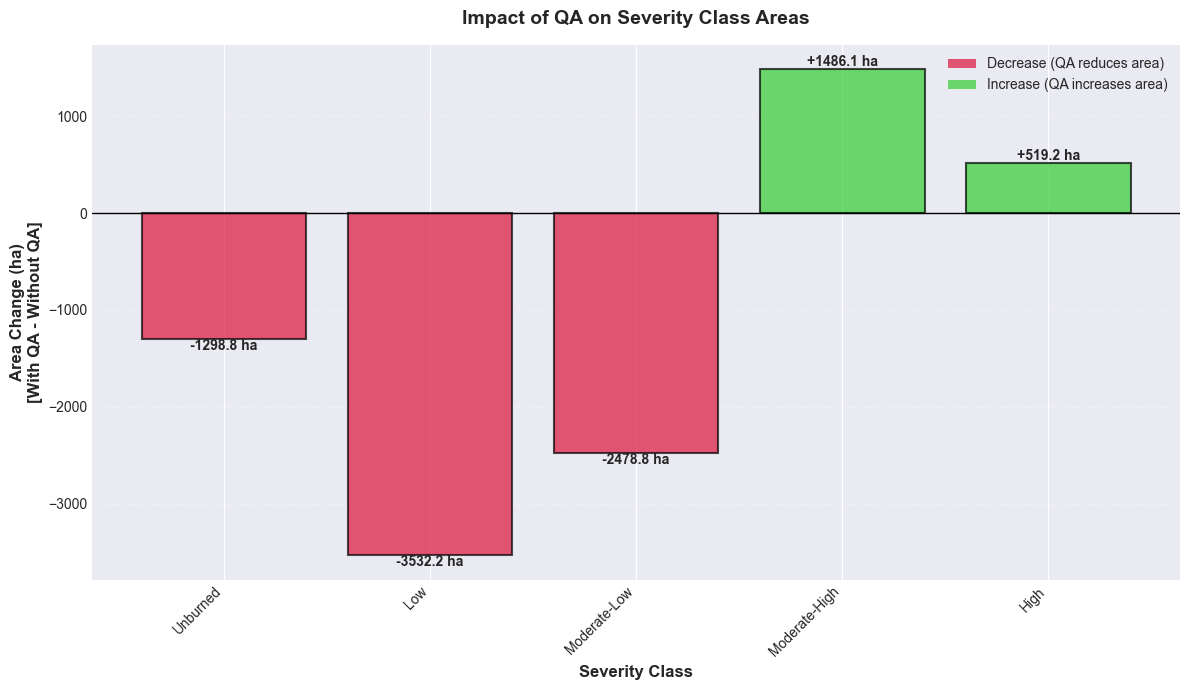

✓ Saved to: c:\Repos\ARua_Wildfire\output\report\severity_change.png


In [15]:
# Create change visualization
fig, ax = plt.subplots(figsize=(12, 7))

# Calculate absolute changes
changes = comparison_df['Difference (ha)'].tolist()

# Color bars by direction (red = decrease, green = increase)
bar_colors = ['#DC143C' if c < 0 else '#32CD32' for c in changes]

bars = ax.bar(severity_classes, changes, color=bar_colors, alpha=0.7, 
              edgecolor='black', linewidth=1.5)

# Add value labels
for bar, val in zip(bars, changes):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:+.1f} ha',
            ha='center', va='bottom' if val > 0 else 'top',
            fontweight='bold', fontsize=10)

ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('Severity Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Area Change (ha)\n[With QA - Without QA]', fontsize=12, fontweight='bold')
ax.set_title('Impact of QA on Severity Class Areas', fontsize=14, fontweight='bold', pad=15)
ax.set_xticklabels(severity_classes, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#DC143C', alpha=0.7, label='Decrease (QA reduces area)'),
    Patch(facecolor='#32CD32', alpha=0.7, label='Increase (QA increases area)')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, 'severity_change.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved to: {os.path.join(REPORT_DIR, 'severity_change.png')}")

In [16]:
# Assess whether changes are meaningful
print("\n" + "="*80)
print("STATISTICAL SIGNIFICANCE ASSESSMENT")
print("="*80)

# Define thresholds for "meaningful" change
MEANINGFUL_ABSOLUTE_HA = 10  # hectares
MEANINGFUL_RELATIVE_PCT = 10  # percent

print(f"\nThresholds for 'meaningful' change:")
print(f"  - Absolute: ±{MEANINGFUL_ABSOLUTE_HA} ha")
print(f"  - Relative: ±{MEANINGFUL_RELATIVE_PCT}%")

print("\n" + "-"*80)

for idx, row in comparison_df.iterrows():
    severity = row['Severity Class']
    abs_change = row['Difference (ha)']
    rel_change = row['Relative Change (%)']
    
    # Check both thresholds
    abs_meaningful = abs(abs_change) >= MEANINGFUL_ABSOLUTE_HA
    rel_meaningful = abs(rel_change) >= MEANINGFUL_RELATIVE_PCT
    
    if abs_meaningful and rel_meaningful:
        significance = "✓✓ HIGHLY SIGNIFICANT"
    elif abs_meaningful or rel_meaningful:
        significance = "✓ SIGNIFICANT"
    else:
        significance = "○ Not significant"
    
    print(f"{severity:15s}: {abs_change:+7.1f} ha ({rel_change:+6.1f}%) → {significance}")

print("\n" + "="*80)
print("ANSWER TO RESEARCH QUESTION")
print("="*80)

# Check the specific criterion: High → Moderate redistribution
high_meaningful = (abs(high_change) >= MEANINGFUL_ABSOLUTE_HA and 
                   abs(high_change_pct) >= MEANINGFUL_RELATIVE_PCT)
mod_meaningful = (abs(total_mod_change) >= MEANINGFUL_ABSOLUTE_HA and
                  abs((total_mod_change/total_mod_no_qa)*100) >= MEANINGFUL_RELATIVE_PCT)

if high_change < 0 and total_mod_change > 0 and (high_meaningful or mod_meaningful):
    print("\n✓✓ YES - QA MEANINGFULLY CHANGES FIRE SEVERITY RESULTS")
    print(f"\n   Evidence:")
    print(f"   • High severity DECREASED by {abs(high_change):.1f} ha ({abs(high_change_pct):.1f}%)")
    print(f"   • Moderate severity INCREASED by {total_mod_change:.1f} ha")
    print(f"   • Clear structural redistribution: High → Moderate")
elif high_meaningful or mod_meaningful:
    print("\n✓ PARTIAL - QA causes significant changes but not clear High→Moderate redistribution")
    print(f"\n   Evidence:")
    print(f"   • High severity changed by {high_change:+.1f} ha ({high_change_pct:+.1f}%)")
    print(f"   • Moderate severity changed by {total_mod_change:+.1f} ha")
else:
    print("\n○ NO - QA does NOT meaningfully change severity distribution")
    print(f"\n   Evidence:")
    print(f"   • Changes are below significance thresholds")
    print(f"   • High severity: {high_change:+.1f} ha ({high_change_pct:+.1f}%)")
    print(f"   • Moderate severity: {total_mod_change:+.1f} ha")

print("\n" + "="*80)


STATISTICAL SIGNIFICANCE ASSESSMENT

Thresholds for 'meaningful' change:
  - Absolute: ±10 ha
  - Relative: ±10%

--------------------------------------------------------------------------------
Unburned       : -1298.8 ha ( -81.0%) → ✓✓ HIGHLY SIGNIFICANT
Low            : -3532.2 ha ( -69.9%) → ✓✓ HIGHLY SIGNIFICANT
Moderate-Low   : -2478.8 ha ( -16.2%) → ✓✓ HIGHLY SIGNIFICANT
Moderate-High  : +1486.1 ha ( +10.2%) → ✓✓ HIGHLY SIGNIFICANT
High           :  +519.2 ha ( +71.3%) → ✓✓ HIGHLY SIGNIFICANT

ANSWER TO RESEARCH QUESTION

✓ PARTIAL - QA causes significant changes but not clear High→Moderate redistribution

   Evidence:
   • High severity changed by +519.2 ha (+71.3%)
   • Moderate severity changed by -992.7 ha



## 6. Accuracy Metrics Comparison

In [17]:
# Extract accuracy metrics
qa_iou = get_metric_value(qa_metrics_df, 'IoU')
qa_dice = get_metric_value(qa_metrics_df, 'Dice/F1')
qa_precision = get_metric_value(qa_metrics_df, 'Precision')
qa_recall = get_metric_value(qa_metrics_df, 'Recall')

no_qa_iou = get_metric_value(no_qa_metrics_df, 'IoU')
no_qa_dice = get_metric_value(no_qa_metrics_df, 'Dice/F1')
no_qa_precision = get_metric_value(no_qa_metrics_df, 'Precision')
no_qa_recall = get_metric_value(no_qa_metrics_df, 'Recall')

print("\n" + "="*60)
print("ACCURACY METRICS COMPARISON")
print("="*60)
print(f"\n{'Metric':<20} {'With QA':>15} {'Without QA':>15} {'Difference':>15}")
print("-"*60)
print(f"{'IoU (Jaccard)':<20} {qa_iou:>15.4f} {no_qa_iou:>15.4f} {qa_iou - no_qa_iou:>+15.4f}")
print(f"{'Dice/F1':<20} {qa_dice:>15.4f} {no_qa_dice:>15.4f} {qa_dice - no_qa_dice:>+15.4f}")
print(f"{'Precision':<20} {qa_precision:>15.4f} {no_qa_precision:>15.4f} {qa_precision - no_qa_precision:>+15.4f}")
print(f"{'Recall':<20} {qa_recall:>15.4f} {no_qa_recall:>15.4f} {qa_recall - no_qa_recall:>+15.4f}")
print("="*60)


ACCURACY METRICS COMPARISON

Metric                       With QA      Without QA      Difference
------------------------------------------------------------
IoU (Jaccard)                 0.8950          0.8825         +0.0125
Dice/F1                       0.9446          0.9376         +0.0070
Precision                     0.9392          0.8837         +0.0554
Recall                        0.9501          0.9984         -0.0483


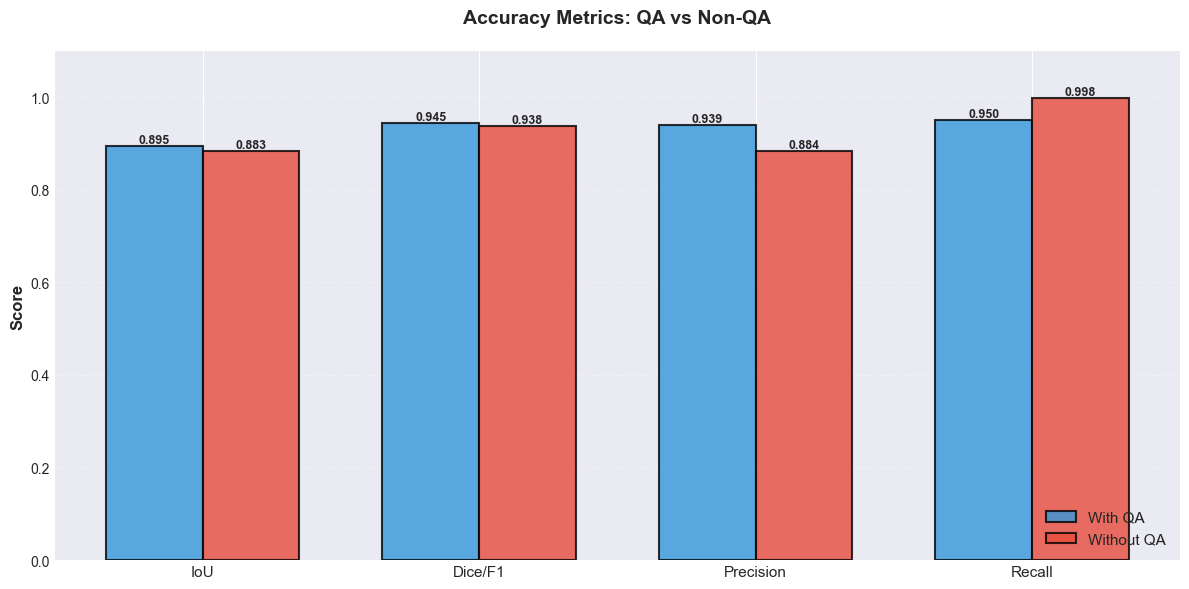

✓ Saved to: c:\Repos\ARua_Wildfire\output\report\accuracy_comparison.png


In [18]:
# Visualize accuracy metrics comparison
fig, ax = plt.subplots(figsize=(12, 6))

metrics_names = ['IoU', 'Dice/F1', 'Precision', 'Recall']
qa_values = [qa_iou, qa_dice, qa_precision, qa_recall]
no_qa_values = [no_qa_iou, no_qa_dice, no_qa_precision, no_qa_recall]

x = np.arange(len(metrics_names))
width = 0.35

bars1 = ax.bar(x - width/2, qa_values, width, label='With QA', 
               color='#3498DB', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, no_qa_values, width, label='Without QA',
               color='#E74C3C', alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Accuracy Metrics: QA vs Non-QA', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=11)
ax.legend(fontsize=11, loc='lower right')
ax.set_ylim([0, 1.1])
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, 'accuracy_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved to: {os.path.join(REPORT_DIR, 'accuracy_comparison.png')}")

## 7. Shape Metrics (Compactness)

In [19]:
# Extract compactness metrics
ref_compact = get_metric_value(qa_metrics_df, 'Reference Compactness')
qa_compact = get_metric_value(qa_metrics_df, 'Predicted Compacteness')
no_qa_compact = get_metric_value(no_qa_metrics_df, 'Predicted Compacteness')

print("\n" + "="*60)
print("SHAPE COMPACTNESS COMPARISON")
print("="*60)
print("\nCompactness = 4πA/P² (1.0 = perfect circle, lower = more irregular)\n")
print(f"Reference:                {ref_compact:>10.4f}")
print(f"Predicted (with QA):      {qa_compact:>10.4f}")
print(f"Predicted (without QA):   {no_qa_compact:>10.4f}")
print(f"\nDifference (QA impact):   {qa_compact - no_qa_compact:>+10.4f}")
print("="*60)


SHAPE COMPACTNESS COMPARISON

Compactness = 4πA/P² (1.0 = perfect circle, lower = more irregular)

Reference:                    0.0005
Predicted (with QA):          0.0039
Predicted (without QA):       0.0306

Difference (QA impact):      -0.0267


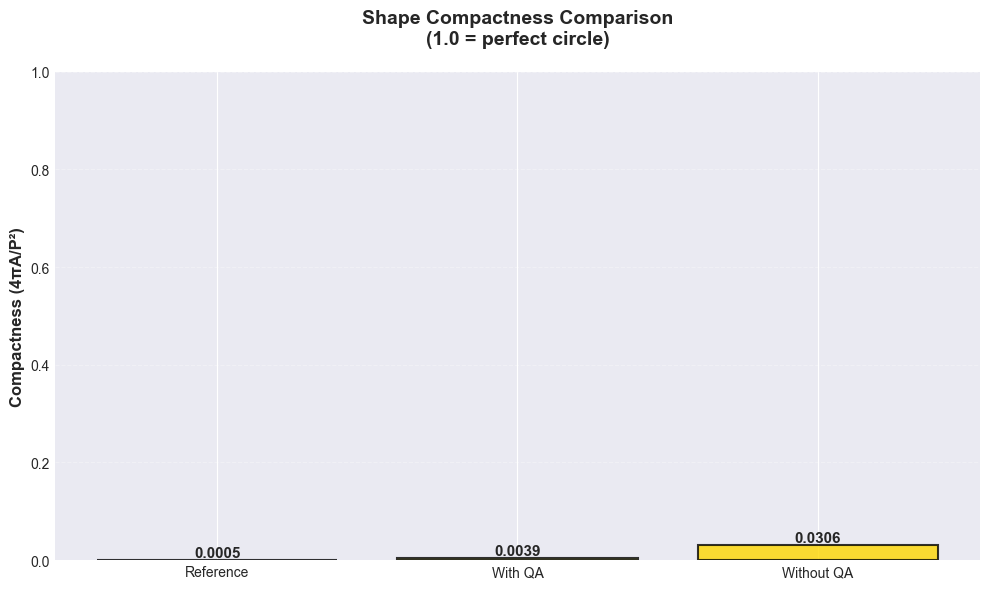

✓ Saved to: c:\Repos\ARua_Wildfire\output\report\compactness_comparison.png


In [20]:
# Visualize compactness
fig, ax = plt.subplots(figsize=(10, 6))

compactness_values = [ref_compact, qa_compact, no_qa_compact]

bars = ax.bar(categories, compactness_values, color=colors, alpha=0.8, 
              edgecolor='black', linewidth=1.5)

# Add value labels
for bar, val in zip(bars, compactness_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylabel('Compactness (4πA/P²)', fontsize=12, fontweight='bold')
ax.set_title('Shape Compactness Comparison\n(1.0 = perfect circle)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_ylim([0, 1.0])
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, 'compactness_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved to: {os.path.join(REPORT_DIR, 'compactness_comparison.png')}")

## 8. Error Analysis (False Positives & False Negatives)

In [21]:
# Extract error metrics
qa_fp = get_metric_value(qa_metrics_df, 'False Positive (ha)')
qa_fn = get_metric_value(qa_metrics_df, 'False_Negative (ha)')

no_qa_fp = get_metric_value(no_qa_metrics_df, 'False Positive (ha)')
no_qa_fn = get_metric_value(no_qa_metrics_df, 'False_Negative (ha)')

print("\n" + "="*60)
print("ERROR ANALYSIS")
print("="*60)
print(f"\n{'Error Type':<25} {'With QA':>15} {'Without QA':>15}")
print("-"*60)
print(f"{'False Positive (ha)':<25} {qa_fp:>15.2f} {no_qa_fp:>15.2f}")
print(f"{'False Negative (ha)':<25} {qa_fn:>15.2f} {no_qa_fn:>15.2f}")
print(f"{'Total Error (ha)':<25} {qa_fp + qa_fn:>15.2f} {no_qa_fp + no_qa_fn:>15.2f}")
print("="*60)


ERROR ANALYSIS

Error Type                        With QA      Without QA
------------------------------------------------------------
False Positive (ha)               2030.82         4334.46
False Negative (ha)               1646.40           52.28
Total Error (ha)                  3677.22         4386.74


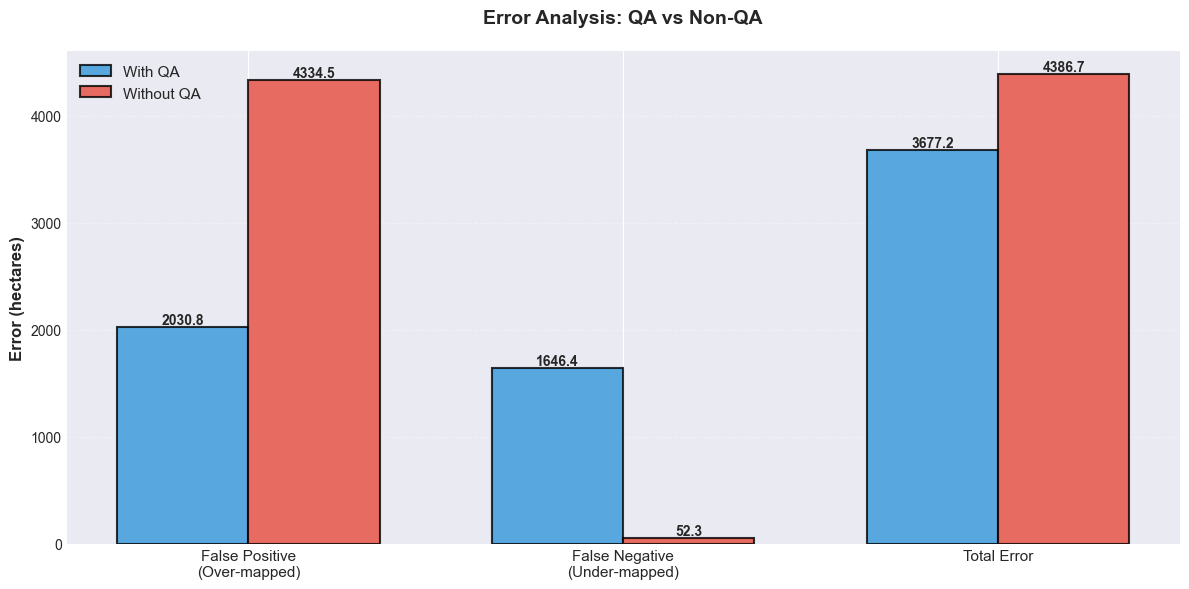

✓ Saved to: c:\Repos\ARua_Wildfire\output\report\error_analysis.png


In [22]:
# Visualize errors
fig, ax = plt.subplots(figsize=(12, 6))

error_types = ['False Positive\n(Over-mapped)', 'False Negative\n(Under-mapped)', 'Total Error']
qa_errors = [qa_fp, qa_fn, qa_fp + qa_fn]
no_qa_errors = [no_qa_fp, no_qa_fn, no_qa_fp + no_qa_fn]

x = np.arange(len(error_types))
width = 0.35

bars1 = ax.bar(x - width/2, qa_errors, width, label='With QA',
               color='#3498DB', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, no_qa_errors, width, label='Without QA',
               color='#E74C3C', alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Error (hectares)', fontsize=12, fontweight='bold')
ax.set_title('Error Analysis: QA vs Non-QA', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(error_types, fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, 'error_analysis.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved to: {os.path.join(REPORT_DIR, 'error_analysis.png')}")

## 9. Spatial Visualization (Polygons Overlay)

In [23]:
# Load polygon geometries
try:
    reference_gdf = gpd.read_file(REFERENCE_POLYGON)
    qa_gdf = gpd.read_file(QA_POLYGON)
    no_qa_gdf = gpd.read_file(NO_QA_POLYGON)
    
    # Ensure same CRS
    if reference_gdf.crs != qa_gdf.crs:
        reference_gdf = reference_gdf.to_crs(qa_gdf.crs)
    if reference_gdf.crs != no_qa_gdf.crs:
        no_qa_gdf = no_qa_gdf.to_crs(qa_gdf.crs)
    
    print("✓ Polygons loaded successfully")
    print(f"  Reference CRS: {reference_gdf.crs}")
    print(f"  QA polygon CRS: {qa_gdf.crs}")
    print(f"  Non-QA polygon CRS: {no_qa_gdf.crs}")
    
except FileNotFoundError as e:
    print(f"❌ Error loading polygons: {e}")
    print("Skipping spatial visualization")

✓ Polygons loaded successfully
  Reference CRS: EPSG:32629
  QA polygon CRS: EPSG:32629
  Non-QA polygon CRS: EPSG:32629


C:\Users\User\AppData\Local\Temp\ipykernel_23864\2010046581.py:23: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax2.legend(fontsize=11, loc='best', framealpha=0.9)
C:\Users\User\AppData\Local\Temp\ipykernel_23864\2010046581.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(fontsize=11, loc='best', framealpha=0.9)


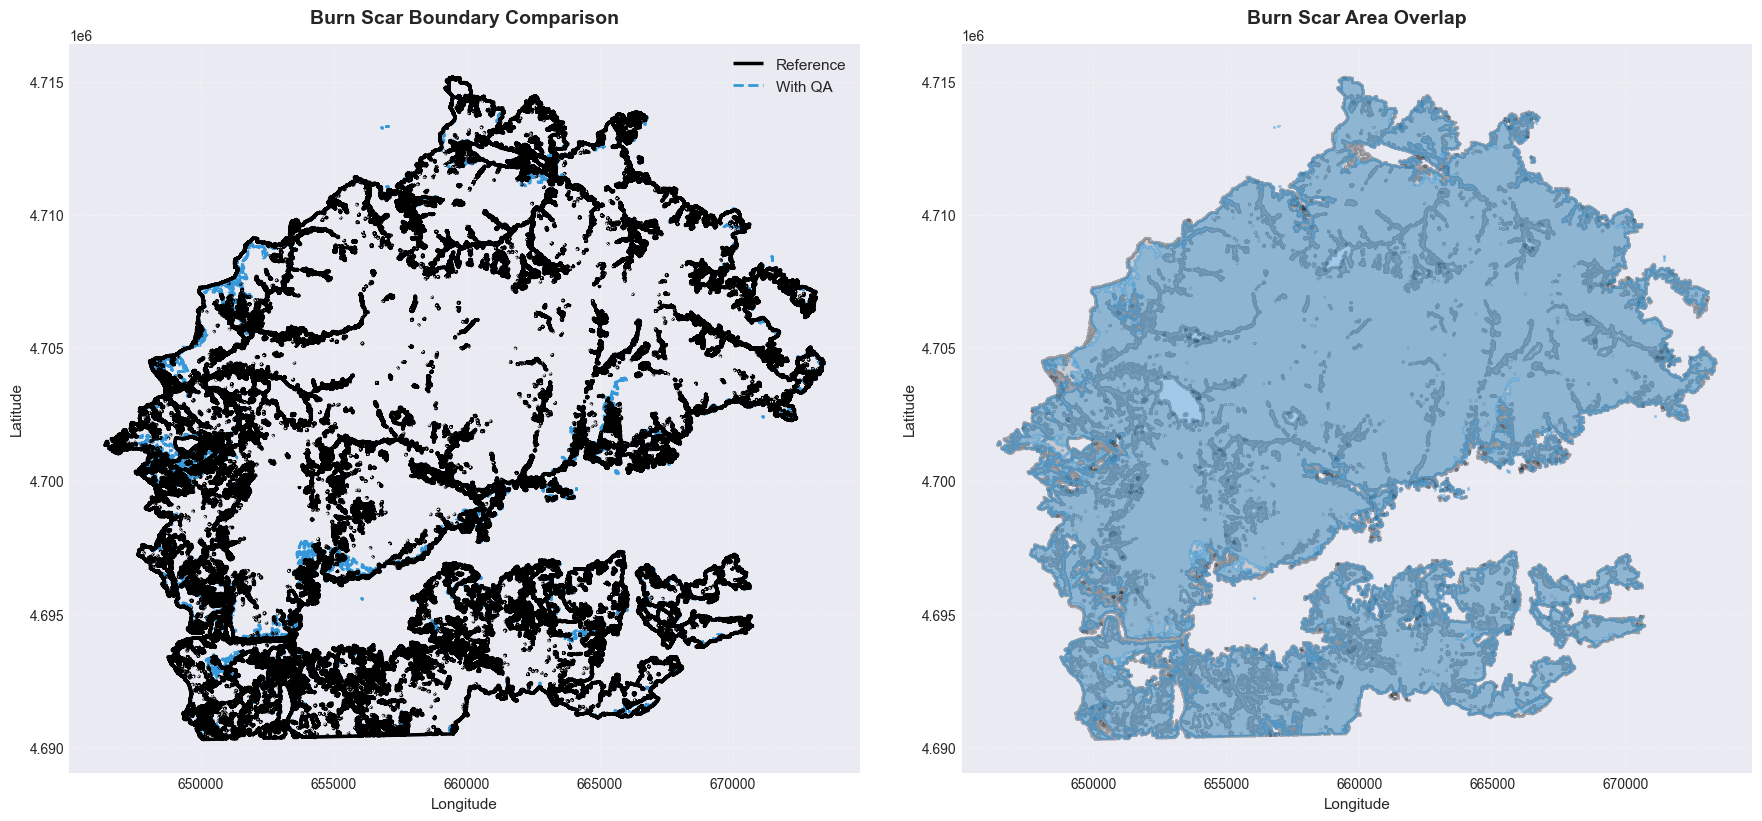

✓ Saved to: c:\Repos\ARua_Wildfire\output\report\spatial_comparison.png


In [24]:
# Create spatial comparison plot
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left plot: All boundaries overlaid
ax1 = axes[0]
reference_gdf.boundary.plot(ax=ax1, color='black', linewidth=2.5, label='Reference', zorder=3)
qa_gdf.boundary.plot(ax=ax1, color='#3498DB', linewidth=2, label='With QA', linestyle='--', zorder=2)
#no_qa_gdf.boundary.plot(ax=ax1, color='#E74C3C', linewidth=2, label='Without QA', linestyle=':', zorder=1)

ax1.set_title('Burn Scar Boundary Comparison', fontsize=14, fontweight='bold', pad=15)
ax1.legend(fontsize=11, loc='best', framealpha=0.9)
ax1.set_xlabel('Longitude', fontsize=11)
ax1.set_ylabel('Latitude', fontsize=11)
ax1.grid(True, alpha=0.3, linestyle='--')

# Right plot: Filled polygons with transparency
ax2 = axes[1]
reference_gdf.plot(ax=ax2, color='gray', alpha=0.3, edgecolor='black', linewidth=2, label='Reference')
qa_gdf.plot(ax=ax2, color='#3498DB', alpha=0.4, edgecolor='#3498DB', linewidth=1.5, label='With QA')
#no_qa_gdf.plot(ax=ax2, color='#E74C3C', alpha=0.4, edgecolor='#E74C3C', linewidth=1.5, label='Without QA')

ax2.set_title('Burn Scar Area Overlap', fontsize=14, fontweight='bold', pad=15)
ax2.legend(fontsize=11, loc='best', framealpha=0.9)
ax2.set_xlabel('Longitude', fontsize=11)
ax2.set_ylabel('Latitude', fontsize=11)
ax2.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, 'spatial_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved to: {os.path.join(REPORT_DIR, 'spatial_comparison.png')}")

## 10. Summary Table

In [25]:
# Create comprehensive summary table
summary_data = {
    'Metric': [
        'Perimeter (km)',
        'Perimeter Diff from Ref (%)',
        'Area (ha)',
        'Area Diff from Ref (%)',
        'IoU (Jaccard)',
        'Dice/F1',
        'Precision',
        'Recall',
        'False Positive (ha)',
        'False Negative (ha)',
        'Compactness'
    ],
    'Reference': [
        ref_perimeter,
        0.0,
        ref_area,
        0.0,
        1.0,
        1.0,
        1.0,
        1.0,
        0.0,
        0.0,
        ref_compact
    ],
    'With QA': [
        qa_perimeter,
        qa_perim_diff_pct,
        qa_area,
        qa_area_diff_pct,
        qa_iou,
        qa_dice,
        qa_precision,
        qa_recall,
        qa_fp,
        qa_fn,
        qa_compact
    ],
    'Without QA': [
        no_qa_perimeter,
        no_qa_perim_diff_pct,
        no_qa_area,
        no_qa_area_diff_pct,
        no_qa_iou,
        no_qa_dice,
        no_qa_precision,
        no_qa_recall,
        no_qa_fp,
        no_qa_fn,
        no_qa_compact
    ]
}

summary_df = pd.DataFrame(summary_data)

# Calculate QA impact (difference between with QA and without QA)
summary_df['QA Impact'] = summary_df['With QA'] - summary_df['Without QA']

# Display
print("\n" + "="*80)
print("COMPREHENSIVE COMPARISON SUMMARY")
print("="*80)
display(summary_df.style.format({
    'Reference': '{:.4f}',
    'With QA': '{:.4f}',
    'Without QA': '{:.4f}',
    'QA Impact': '{:+.4f}'
}))

# Save to CSV
summary_path = os.path.join(REPORT_DIR, 'comparison_summary.csv')
summary_df.to_csv(summary_path, index=False)
print(f"\n✓ Summary table saved to: {summary_path}")


COMPREHENSIVE COMPARISON SUMMARY


,Metric,Reference,With QA,Without QA,QA Impact
0,Perimeter (km),2814.1128,1041.2400,391.4400,+649.8000
1,Perimeter Diff from Ref (%),0.0000,-62.9994,-86.0901,+23.0908
2,Area (ha),33002.9425,33387.3600,37285.1200,-3897.7600
3,Area Diff from Ref (%),0.0000,1.1648,12.9751,-11.8103
4,IoU (Jaccard),1.0000,0.8950,0.8825,+0.0125
5,Dice/F1,1.0000,0.9446,0.9376,+0.0070
6,Precision,1.0000,0.9392,0.8837,+0.0554
7,Recall,1.0000,0.9501,0.9984,-0.0483
8,False Positive (ha),0.0000,2030.8169,4334.4572,-2303.6403
9,False Negative (ha),0.0000,1646.3994,52.2797,+1594.1197



✓ Summary table saved to: c:\Repos\ARua_Wildfire\output\report\comparison_summary.csv


## 11. Key Findings and Interpretation

In [26]:
# Generate automated findings
print("\n" + "="*80)
print("KEY FINDINGS")
print("="*80)

# Perimeter findings
perim_change = ((qa_perimeter / no_qa_perimeter - 1) * 100)
if abs(perim_change) < 1:
    perim_interpretation = "minimal impact"
elif perim_change < -5:
    perim_interpretation = "significant reduction (smoother boundaries)"
elif perim_change > 5:
    perim_interpretation = "significant increase (more fragmented)"
else:
    perim_interpretation = "moderate change"

print(f"\n1. PERIMETER IMPACT:")
print(f"   QA masks caused a {perim_change:+.2f}% change in perimeter.")
print(f"   Interpretation: {perim_interpretation}")

# Accuracy findings
iou_change = qa_iou - no_qa_iou
if iou_change > 0.05:
    accuracy_interpretation = "QA masks IMPROVED accuracy significantly"
elif iou_change > 0:
    accuracy_interpretation = "QA masks slightly improved accuracy"
elif iou_change > -0.05:
    accuracy_interpretation = "QA masks slightly reduced accuracy"
else:
    accuracy_interpretation = "QA masks REDUCED accuracy significantly"

print(f"\n2. ACCURACY IMPACT:")
print(f"   IoU changed by {iou_change:+.4f} (from {no_qa_iou:.4f} to {qa_iou:.4f})")
print(f"   Interpretation: {accuracy_interpretation}")

# Error analysis
total_error_qa = qa_fp + qa_fn
total_error_no_qa = no_qa_fp + no_qa_fn
error_reduction = ((total_error_qa / total_error_no_qa - 1) * 100)

print(f"\n3. ERROR REDUCTION:")
print(f"   Total error changed by {error_reduction:+.2f}%")
print(f"   (from {total_error_no_qa:.2f} ha to {total_error_qa:.2f} ha)")

# Precision vs Recall trade-off
precision_change = qa_precision - no_qa_precision
recall_change = qa_recall - no_qa_recall

print(f"\n4. PRECISION-RECALL TRADE-OFF:")
print(f"   Precision: {precision_change:+.4f} (from {no_qa_precision:.4f} to {qa_precision:.4f})")
print(f"   Recall: {recall_change:+.4f} (from {no_qa_recall:.4f} to {qa_recall:.4f})")

if precision_change > 0 and recall_change < 0:
    print("   Trade-off: QA increased precision but reduced recall (more conservative)")
elif precision_change < 0 and recall_change > 0:
    print("   Trade-off: QA reduced precision but increased recall (more liberal)")
elif precision_change > 0 and recall_change > 0:
    print("   Win-win: QA improved both precision and recall!")
else:
    print("   Loss-loss: QA reduced both precision and recall")

print("\n" + "="*80)


KEY FINDINGS

1. PERIMETER IMPACT:
   QA masks caused a +166.00% change in perimeter.
   Interpretation: significant increase (more fragmented)

2. ACCURACY IMPACT:
   IoU changed by +0.0125 (from 0.8825 to 0.8950)
   Interpretation: QA masks slightly improved accuracy

3. ERROR REDUCTION:
   Total error changed by -16.17%
   (from 4386.74 ha to 3677.22 ha)

4. PRECISION-RECALL TRADE-OFF:
   Precision: +0.0554 (from 0.8837 to 0.9392)
   Recall: -0.0483 (from 0.9984 to 0.9501)
   Trade-off: QA increased precision but reduced recall (more conservative)



## 12. Conclusions and Recommendations

### Study Context

This report evaluates the impact of multi-layer quality assurance on NBR-based burn severity mapping for the **August 2025 Larouco-Seadur wildfire** in the **Valdeorras region (A Rúa, Ourense, Galicia)**. The fire affected over 30,000 hectares across extreme terrain, with elevations ranging from ~300 m in the Sil valley floor to over 1,200 m at Cabeza Porriñas. This relief makes it a particularly demanding test case for remote sensing analysis.

Two pipelines were compared against **Copernicus EMS EMSR837** reference data (454 features, 33,003 ha):

- **Non-curated pipeline**: Basic NBR from raw L2A bands, threshold 0.1, min_area 15 ha
- **Curated pipeline**: 9 QA layers + topographic correction (SCS+C), threshold 0.3, min_area 0.1 ha, kernel (1,1)

---

### Key Findings

**1. QA improved precision without sacrificing recall**

The curated pipeline achieved IoU 89.5%, precision 93.9%, and recall 95.0%. The most significant gain was in precision (+6.3 pp over the non-curated pipeline), meaning substantially fewer hectares were falsely classified as burned. False positives dropped from 14.1% to 6.1% of the reference area — a reduction of over 2,600 ha of misclassified terrain. This is the primary operational value of the QA approach: fewer resources directed at areas that did not actually burn.

**2. Area estimation became highly accurate**

The curated pipeline predicted 33,387 ha versus 33,003 ha reference — a difference of only +1.16%. The non-curated pipeline overestimated by +13.7% (37,535 ha), largely due to shaded slopes and bright surfaces being misclassified. The topographic correction was the key driver of this improvement, normalizing illumination differences across the steep terrain of Valdeorras.

**3. Severity redistribution: Low → High**

The most consequential finding is the upward shift in severity classification. The curated pipeline detected significantly more High severity (+519 ha, +71%) and Moderate-High severity (+1,486 ha, +10%) compared to the non-curated approach, while Low severity dropped by 3,532 ha (-70%) and Unburned within the perimeter decreased by 1,299 ha (-81%).

This is physically consistent: the non-curated pipeline included large amounts of noise — unmasked cloud shadows, smoke-affected pixels, edge artifacts, and non-vegetated surfaces — that diluted the dNBR signal within the burn perimeter. These contaminated pixels registered low or zero dNBR values, inflating the Low and Unburned classes. After QA masking removed these artifacts, the remaining valid pixels represent actual burn damage, revealing the true severity distribution.

Additionally, the SCS+C topographic correction recovered burn signal on south-facing slopes where excess illumination was suppressing dNBR values, pushing pixels that appeared as Moderate-Low into their correct Moderate-High or High categories.

The implication is significant: **the non-curated pipeline underestimates fire damage**. Using it for post-fire management would result in underallocation of restoration resources and underestimation of ecological impact and carbon loss.

**4. Topographic correction was the most impactful QA layer**

Among the 9 QA layers applied (cloud mask, smoke detection, atmospheric validation, saturation, outlier detection, edge artifacts, vegetation mask, bright surface mask, and SCS+C topographic correction), the SCS+C correction had the largest individual impact. In terrain with over 900 m of elevation range, north-facing slopes in shadow had artificially low reflectance while south-facing slopes had artificially high reflectance, distorting the NBR in both directions. The correction enabled raising the dNBR threshold from 0.1 to 0.3 while maintaining 95% recall — a threshold that would have been too aggressive without illumination normalization.

**5. The perimeter gap is a resolution limitation, not a pipeline deficiency**

The predicted perimeter (1,041 km) remains substantially below the reference (2,814 km), with 475 features versus 454. This gap is structural: Copernicus EMS uses very high resolution imagery (Pléiades, WorldView at 0.5–1.5 m) producing highly irregular boundaries, while Sentinel-2 at 20 m resolution inherently generates smoother polygons. Each 20 m pixel boundary contributes a fixed perimeter increment where the reference may have 40–80 m of irregular contour in the same space. This is not correctable within the Sentinel-2 workflow and should not be interpreted as a detection failure.

---

### QA Layers Applied

| Layer | Type | Purpose |
|---|---|---|
| Cloud mask | Sensor QA | Exclude clouds (medium, high, cirrus) and cloud shadows from SCL |
| Smoke mask | Sensor QA | Detect residual smoke in post-fire imagery |
| Atmospheric validation | Diagnostic | Verify L2A correction quality via AOT/WVP thresholds |
| Saturation mask | Radiometric QA | Exclude pixels where B8A or B12 exceed sensor dynamic range |
| Outlier detection | Statistical QA | Flag extreme reflectance values indicating unmasked artifacts |
| Edge mask | Geometric QA | Buffer unreliable pixels near image boundaries |
| Vegetation mask (NDVI) | Thematic QA | Restrict pre-fire analysis to vegetated areas only |
| Bright surface mask | Thematic QA | Exclude bare soil, concrete, and other high-albedo surfaces |
| SCS+C topographic correction | Radiometric correction | Normalize B8A and B12 for terrain illumination effects |

---

### Limitations

- **Spatial resolution**: Sentinel-2 at 20 m cannot reproduce the boundary detail of VHR-based reference data. Perimeter and compactness metrics will always underperform against Copernicus EMS.
- **No water mask**: The Sil river and San Martiño reservoir cross the AOI. Water bodies have low NBR that can mimic severe burn. A dedicated NDWI-based mask would improve precision in riparian areas.
- **Single event validation**: Results are specific to the August 2025 Larouco-Seadur fire. Generalizability to other fire regimes, vegetation types, and terrain configurations requires further testing.
- **Temporal baseline**: Only one pre-fire and one post-fire date were used. Multi-temporal compositing could reduce noise from atmospheric or phenological variability.
- **Severity thresholds**: USGS dNBR thresholds were applied as-is. Regional calibration with field-measured Composite Burn Index (CBI) data would improve severity class boundaries for Atlantic forests.

---

### Recommendations

1. **Adopt the curated pipeline for operational burn mapping in mountainous terrain**. The +6 pp precision gain and accurate area estimation (+1.16%) justify the additional processing cost.
2. **Add a water mask** using NDWI (B03, B8A) to eliminate false positives along the Sil corridor and reservoir margins.
3. **Validate severity classes with field data**. The Low → High redistribution is physically plausible but should be confirmed with CBI measurements to calibrate region-specific thresholds.
4. **Test on additional Galician fire events** (e.g., Oímbra-Xinzo 2025, Chandrexa de Queixa 2025) to assess whether the topographic correction benefit generalizes across the province.
5. **Do not use perimeter as a primary accuracy metric** when comparing Sentinel-2 outputs against VHR-derived reference data. IoU, precision, and recall are resolution-appropriate metrics.


---

**Report Generated:** [Run date/time will be auto-populated]

**All outputs saved to:** `output/report/`